<a href="https://colab.research.google.com/github/Shavkatov-dev/computer_vision/blob/main/pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
pip install torch

In [4]:
# Import PyTorch
import torch
from torch import nn

In [5]:
print(torch.__version__)

2.11.0+cu128


In [6]:
print("CUDA available:", torch.cuda.is_available())

CUDA available: True


In [7]:
scalar = torch.tensor(5)
print('scalar', scalar)
print('scalar shape', scalar.shape)

scalar tensor(5)
scalar shape torch.Size([])


In [8]:
vector = torch.tensor([1, 2, 3])
print('vector', vector)
print('vector shape', vector.shape)
print("Number of dimension", vector.ndim)
print("Size:", vector.size())

vector tensor([1, 2, 3])
vector shape torch.Size([3])
Number of dimension 1
Size: torch.Size([3])


In [9]:
MATRIX = torch.tensor([[1, 2, 6], [3, 4, 5]])
print('MATRIX', MATRIX)
print('MATRIX shape', MATRIX.shape)
print("Number of dimension", MATRIX.ndim)
print("Size:", MATRIX.size())

MATRIX tensor([[1, 2, 6],
        [3, 4, 5]])
MATRIX shape torch.Size([2, 3])
Number of dimension 2
Size: torch.Size([2, 3])


In [10]:
tensor3d = torch.stack([MATRIX, MATRIX + 10])
print('tensor3d', tensor3d)

print('tensor3d shape', tensor3d.shape) #[2, 2, 3] 2 matrices => stack ; 2 rows, 2 columns (height, width) [C, H, W]
print("Number of dimension", tensor3d.ndim)
print("Size:", tensor3d.size())

tensor3d tensor([[[ 1,  2,  6],
         [ 3,  4,  5]],

        [[11, 12, 16],
         [13, 14, 15]]])
tensor3d shape torch.Size([2, 2, 3])
Number of dimension 3
Size: torch.Size([2, 2, 3])


In [11]:
random_nums= torch.rand(2, 3) # 0 ~ 1
print('random_nums', random_nums)
print('random_nums type', random_nums.dtype)
print("Number of dimension", random_nums.ndim)
print("Size:", random_nums.size())
print("DEvice of random_nums: ", random_nums.device)

random_nums tensor([[0.3067, 0.4733, 0.9157],
        [0.8185, 0.8704, 0.3954]])
random_nums type torch.float32
Number of dimension 2
Size: torch.Size([2, 3])
DEvice of random_nums:  cpu


In [12]:
print("Zeros: ", torch.zeros(2, 3))


Zeros:  tensor([[0., 0., 0.],
        [0., 0., 0.]])


In [13]:
print("Ones:", torch.ones(2, 3))

Ones: tensor([[1., 1., 1.],
        [1., 1., 1.]])


In [14]:
z = torch.tensor([[1, 2],
                  [3, 4]])

y = torch.tensor([[5, 6],
                  [7, 8]])

#Element-wise addition

print("Addition: ", z + y)

#Element-wise subtraction

print("Subtraction: ", z - y)

#Element-wise multiplication

print("Multiplication: ", z * y)

#Matric multiplication dot product

print("Multiplication: ", z @ y)

#Element-wise division

print("Division: ", y / z)

Addition:  tensor([[ 6,  8],
        [10, 12]])
Subtraction:  tensor([[-4, -4],
        [-4, -4]])
Multiplication:  tensor([[ 5, 12],
        [21, 32]])
Multiplication:  tensor([[19, 22],
        [43, 50]])
Division:  tensor([[5.0000, 3.0000],
        [2.3333, 2.0000]])


In [15]:
# Import PyTorch and matplotlib
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks nn module
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.11.0+cu128'

In [16]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cuda


In [17]:


# Create weight and bias
weight = 0.7
bias = 0.3

# Create range values
start = 0
end = 1
step = 0.02

# Create X and y (features and labels)
X = torch.arange(start, end, step).unsqueeze(dim=1) # without unsqueeze, errors will happen later on (shapes within linear layers)
y = weight * X + bias


# Linear Regression: y=kx + b
print("X:", X)
print("Y:", y)

# Split data
train_split = int(0.8 * len(X)) #100 data=> 80% train | 20% test
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test) + len(y_test)

X: tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800],
        [0.2000],
        [0.2200],
        [0.2400],
        [0.2600],
        [0.2800],
        [0.3000],
        [0.3200],
        [0.3400],
        [0.3600],
        [0.3800],
        [0.4000],
        [0.4200],
        [0.4400],
        [0.4600],
        [0.4800],
        [0.5000],
        [0.5200],
        [0.5400],
        [0.5600],
        [0.5800],
        [0.6000],
        [0.6200],
        [0.6400],
        [0.6600],
        [0.6800],
        [0.7000],
        [0.7200],
        [0.7400],
        [0.7600],
        [0.7800],
        [0.8000],
        [0.8200],
        [0.8400],
        [0.8600],
        [0.8800],
        [0.9000],
        [0.9200],
        [0.9400],
        [0.9600],
        [0.9800]])
Y: tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
   

(40, 40, 20)

In [29]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  plt.figure(figsize=(10, 7))

  # Ensure all data is on CPU and converted to NumPy for plotting
  train_data = train_data.cpu().numpy()
  train_labels = train_labels.cpu().numpy()
  test_data = test_data.cpu().numpy()
  test_labels = test_labels.cpu().numpy()

  #Plot training data in blue
  plt.scatter(train_data, train_labels, c='b', s=4, label='Training data')

  # Plot test data in green
  plt.scatter(test_data, test_labels, c='g', s=4, label='Testing data')

  if predictions is not None:
    # Ensure predictions are on CPU and converted to NumPy for plotting
    predictions = predictions.cpu().numpy()
    plt.scatter(test_data, predictions, c='r', s=4, label='Predictions')

  plt.legend(prop={'size': 14})

In [19]:
# Subclass nn.Module to make our model
class LinearRegressionModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    # Use nn.Linear() for creating the model parameters
    self.linear_layer = nn.Linear(in_features=1,
                                  out_features=1)

  # Define the forward computation (input data x flows through nn.Linear())
  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)

# Set the manual seed when creating the model (this isn't always needed but is used for demonstrative purposes, try comm
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [20]:
# Create loss function
loss_fn = nn.L1Loss() # Loss Function / MAE - Mean Absolute Error

# Create optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(), # optimize newly created model's parameters
                            lr=0.01)

Text(0.5, 1.0, 'Predictions before training (red = random guesses)')

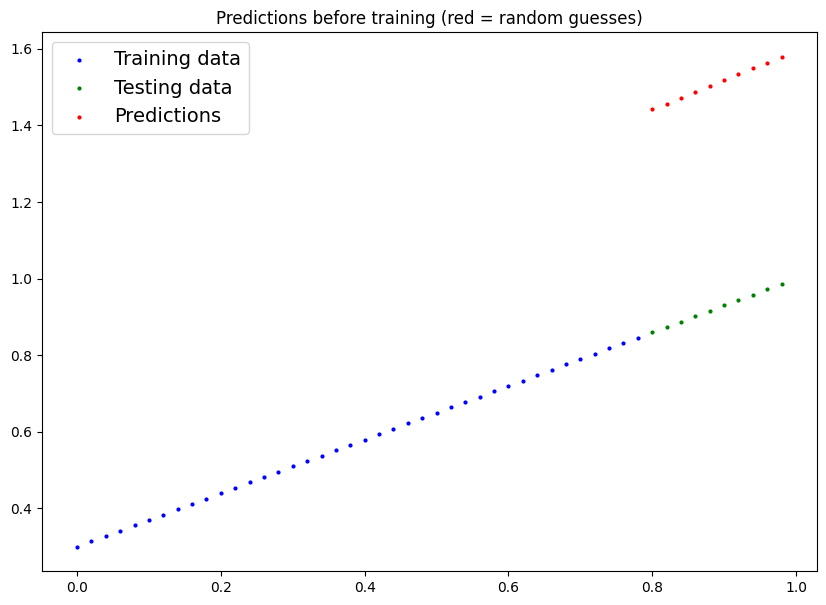

In [22]:
# See model's untrained predictions (on test set)
model_1.eval()
with torch.inference_mode():
  y_preds_early = model_1(X_test) # backwards

plot_predictions(predictions=y_preds_early)
plt.title("Predictions before training (red = random guesses)")

In [24]:
# Set the number of epochs
epochs = 1000

# Put data on the available device
# Without this, error will happen (not all model/data on device)
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

# Move model to the target device
model_1.to(device);

for epoch in range(epochs):
  ### Training
  model_1.train() # train mode is on by default after construction

  # 1. Forward pass
  y_pred = model_1(X_train)

  # 2. Calculate loss
  loss = loss_fn(y_pred, y_train)

  # 3. Zero gradient optimizer
  optimizer.zero_grad()

  # 4. Loss backward
  loss.backward()

  # 5. Step the optimizer
  optimizer.step() #weight and bias values change

  ### Testing
  model_1.eval() # put the model in evaluation mode for testing (inference)
  # 1. Forward pass
  with torch.inference_mode():
    test_pred = model_1(X_test)

    # 2. Calculate the loss
    test_loss = loss_fn(test_pred, y_test)

  # Print out what's happening every 10 epochs
  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Train Loss: {loss} | Test loss: {test_loss}")

Epoch: 0 | Train Loss: 0.5551779270172119 | Test loss: 0.5739762187004089
Epoch: 100 | Train Loss: 0.006215683650225401 | Test loss: 0.014086711220443249
Epoch: 200 | Train Loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 300 | Train Loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 400 | Train Loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 500 | Train Loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 600 | Train Loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 700 | Train Loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 800 | Train Loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 900 | Train Loss: 0.0012645035749301314 | Test loss: 0.013801801018416882


In [26]:
# Turjn model into evaluation mode

model_1.eval()

#Make predictions on the test data
with torch.inference_mode():
  y_preds = model_1(X_test)
y_preds



tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]], device='cuda:0')

Text(0.5, 1.0, 'Predictions after training')

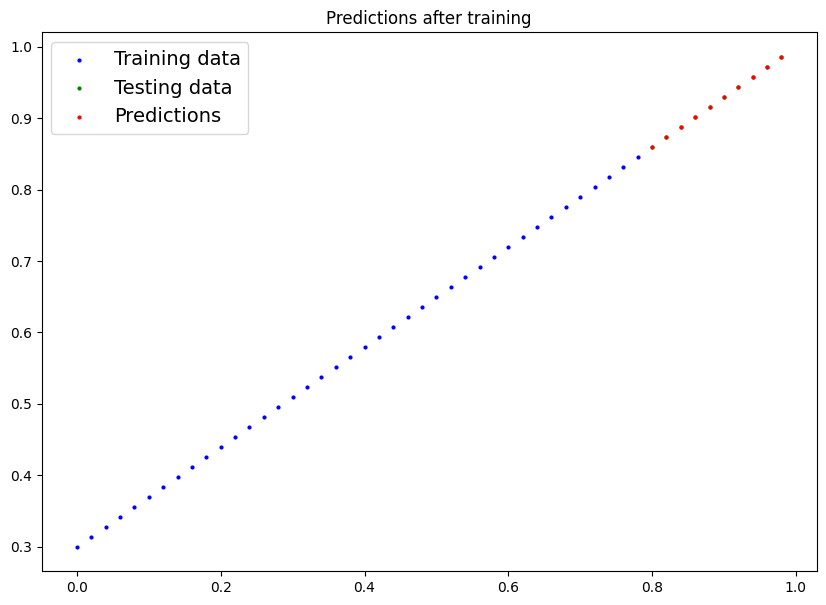

In [30]:
# Plot predictions
plot_predictions(predictions=y_preds)
plt.title("Predictions after training")

In [32]:
torch.save(obj=model_1.state_dict(), f="trained_model.pth")

In [37]:
loaded_model = LinearRegressionModelV2()

loaded_model.load_state_dict(torch.load('/content/trained_model.pth'))

loaded_model.eval()

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)